In [31]:
# =========================
# Environment Init
# =========================
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import sys
from pathlib import Path

def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for p in [current] + list(current.parents):
        if (p / "core").exists() and (p / "notebooks").exists():
            return p
    raise FileNotFoundError("Project root not found.")

PROJECT_ROOT = find_project_root(Path.cwd())

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

os.chdir(PROJECT_ROOT)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("CWD =", os.getcwd())

In [32]:
# =========================
# Imports
# =========================

import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd

from core.db_search import ExactMatchDB
from core.ml_gate import MLGate
from core.evaluator import MachineConfig, PhysicsEvaluator
from core.ga_core import run_ga

print("Imports success")

Imports success


In [33]:
# =========================
# Experiment Config
# =========================

# ---- paths ----
DATA_DIR = Path("data")
MODEL_DIR = Path("models_mlga_v2")
DB_CSV_PATH = DATA_DIR / "mlga_db_v1.csv"

# ---- experiment control ----
RANDOM_SEED = 42

GA_CFG = {
    "pop_size": 3000,
    "n_gen": 100,
    "elite_size": 1,
    "crossover_rate": 0.8,
    "mutation_rate": 0.2,
    "seed": RANDOM_SEED,
}

# ---- MLGA selection ----
MLGA_N_EXPLOIT = 150
MLGA_N_EXPLORE = 150
FEASIBILITY_THRESHOLD = 0.5
UNCERTAINTY_MODE = "normalized_sum"

VERBOSE = True

# ---- machine config ----
MACHINE_CONFIG = dict(
    pole=6,
    a=2,
    Sslot=54,
    Rslot=44,
    SOD=220,
    SID=145,
    hs0=0.4,
    hs1=0.6,
    filled=0.60,
    V1=230,
    f=60,
    kw=0.902,
    length=125,
    gap=0.35,
    br01=0.55,
    br1=1.0,
    Ptarget=3100.0,
    step=0.01,
    max_iter=200000,
)

# ---- GA bounds (must match ga_core.py format) ----
BOUNDS = {
    "bs0":    {"type": "float", "low": 0.1, "high": 3.0},
    "hs2":    {"type": "float", "low": 1.0, "high": 30.0},
    "steeth": {"type": "float", "low": 1.0, "high": 8.0},
    "hr2":    {"type": "float", "low": 1.0, "high": 30.0},
    "rteeth": {"type": "float", "low": 1.0, "high": 8.0},
    "turn":   {"type": "int",   "low": 1,  "high": 60},
}

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("GA_CFG =", GA_CFG)
print("BOUNDS loaded.")

GA_CFG = {'pop_size': 3000, 'n_gen': 100, 'elite_size': 1, 'crossover_rate': 0.8, 'mutation_rate': 0.2, 'seed': 42}
BOUNDS loaded.


In [34]:
# =========================
# DB bootstrap / validation
# =========================

from pathlib import Path
import pandas as pd

print("Checking MLGA DB...")

EXPECTED_COLUMNS = [
    "bs0","hs2","steeth","hr2","rteeth","turn",
    "ok_true","reason_true",
    "eff_true","Tstp_true","Tmscore_true","Ilimite_true","pf_true",
    "Pin_true","Pout_true","loss_true",
    "R1","R2","s","X1","X2","Im","Coreloss",
    "I11_real","I11_imag","I11_abs",
    "true_score",
    "fitness_source",
    "selected_for_physics"
]

def create_empty_db(path):

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    df = pd.DataFrame(columns=EXPECTED_COLUMNS)
    df.to_csv(path, index=False)

    print("Created empty DB:", path)
    return df


if not DB_CSV_PATH.exists():

    print("DB file not found.")
    db_df = create_empty_db(DB_CSV_PATH)

else:

    print("DB file found:", DB_CSV_PATH)

    try:
        db_df = pd.read_csv(DB_CSV_PATH)

        print("Current DB rows:", len(db_df))

        # -----------------------
        # remove duplicated columns
        # -----------------------

        if db_df.columns.duplicated().any():

            print("Duplicated columns detected. Cleaning...")

            db_df = db_df.loc[:, ~db_df.columns.duplicated()].copy()

        # -----------------------
        # check missing columns
        # -----------------------

        missing = [c for c in EXPECTED_COLUMNS if c not in db_df.columns]

        if missing:

            print("Missing columns detected:", missing)

            for col in missing:
                db_df[col] = pd.NA

        # -----------------------
        # reorder columns
        # -----------------------

        db_df = db_df[EXPECTED_COLUMNS]

        # -----------------------
        # save cleaned version
        # -----------------------

        db_df.to_csv(DB_CSV_PATH, index=False)

        print("DB schema validated.")

    except Exception as e:

        print("DB corrupted:", e)
        print("Recreating DB...")

        db_df = create_empty_db(DB_CSV_PATH)


print("DB ready.")
print("Rows:", len(db_df))
print("Columns:", len(db_df.columns))

Checking MLGA DB...
DB file found: data/mlga_db_v1.csv
Current DB rows: 0
DB schema validated.
DB ready.
Rows: 0
Columns: 29


In [35]:
tmp = pd.read_csv(DB_CSV_PATH)
print(tmp.columns.tolist())
print("Duplicated columns:", tmp.columns[tmp.columns.duplicated()].tolist())

['bs0', 'hs2', 'steeth', 'hr2', 'rteeth', 'turn', 'ok_true', 'reason_true', 'eff_true', 'Tstp_true', 'Tmscore_true', 'Ilimite_true', 'pf_true', 'Pin_true', 'Pout_true', 'loss_true', 'R1', 'R2', 's', 'X1', 'X2', 'Im', 'Coreloss', 'I11_real', 'I11_imag', 'I11_abs', 'true_score', 'fitness_source', 'selected_for_physics']
Duplicated columns: []


In [36]:
# =========================
# Build shared objects
# =========================

db = ExactMatchDB.from_csv(DB_CSV_PATH)

gate = MLGate.from_model_dir(
    model_dir=MODEL_DIR,
    feasibility_threshold=FEASIBILITY_THRESHOLD,
    uncertainty_mode=UNCERTAINTY_MODE,
)

machine_config = MachineConfig(**MACHINE_CONFIG)
evaluator = PhysicsEvaluator(machine_config)

print("DB size:", len(db))
print("MLGate ready")
print("Evaluator ready")

DB size: 0
MLGate ready
Evaluator ready


In [37]:
# =========================
# Cell 5. Utility helpers
# =========================

def now():
    return time.perf_counter()

def elapsed(t0):
    return time.perf_counter() - t0

def summarize_generation_result(generation_result_df: pd.DataFrame) -> dict:
    out = {}
    out["population_size"] = len(generation_result_df)

    if "fitness_source" in generation_result_df.columns:
        out["fitness_source_counts"] = generation_result_df["fitness_source"].value_counts(dropna=False).to_dict()
    else:
        out["fitness_source_counts"] = {}

    if "final_fitness" in generation_result_df.columns and len(generation_result_df) > 0:
        out["best_final_fitness"] = generation_result_df["final_fitness"].min()
        out["mean_final_fitness"] = generation_result_df["final_fitness"].mean()
    else:
        out["best_final_fitness"] = np.nan
        out["mean_final_fitness"] = np.nan

    if "ok_true" in generation_result_df.columns:
        valid_ok = generation_result_df["ok_true"].dropna()
        out["true_ok_ratio"] = valid_ok.mean() if len(valid_ok) > 0 else np.nan
    else:
        out["true_ok_ratio"] = np.nan

    return out


def population_to_df(population):
    """
    Convert GA population (list[dict]) to DataFrame.
    """
    return pd.DataFrame(population)


def df_to_records(df: pd.DataFrame):
    """
    Convert DataFrame rows to list[dict] records.
    """
    return df.to_dict(orient="records")

In [38]:
# =========================
# Merge generation results
# =========================

def merge_generation_results(
    population_df: pd.DataFrame,
    db_hit_df: pd.DataFrame,
    prediction_df: pd.DataFrame,
    selected_true_df: pd.DataFrame,
) -> pd.DataFrame:
    design_cols = ["bs0", "hs2", "steeth", "hr2", "rteeth", "turn"]

    base = population_df[design_cols].copy().reset_index(drop=True)
    base["row_id"] = np.arange(len(base))

    temp_db = ExactMatchDB()
    base["design_key"] = temp_db.build_key_series(base)

    # DB-hit
    db_hit_part = db_hit_df.copy()
    if len(db_hit_part) > 0:
        db_hit_part["design_key"] = temp_db.build_key_series(db_hit_part[design_cols])
        db_hit_part["fitness_source"] = "db"
        if "true_score" in db_hit_part.columns:
            db_hit_part["final_fitness"] = db_hit_part["true_score"]
    else:
        db_hit_part = pd.DataFrame(columns=["design_key"])

    # prediction
    pred_part = prediction_df.copy()
    if len(pred_part) > 0:
        pred_part["design_key"] = temp_db.build_key_series(pred_part[design_cols])
        pred_part["fitness_source"] = pred_part.get("fitness_source", "ml")
        if "final_fitness" not in pred_part.columns and "surrogate_score" in pred_part.columns:
            pred_part["final_fitness"] = pred_part["surrogate_score"]
    else:
        pred_part = pd.DataFrame(columns=["design_key"])

    # physics
    physics_part = selected_true_df.copy()
    if len(physics_part) > 0:
        physics_part["design_key"] = temp_db.build_key_series(physics_part[design_cols])
        physics_part["fitness_source"] = "physics"
        physics_part["final_fitness"] = physics_part["true_score"]
    else:
        physics_part = pd.DataFrame(columns=["design_key"])

    merged = base.merge(
        pred_part.drop_duplicates(subset=["design_key"], keep="last"),
        on="design_key",
        how="left",
        suffixes=("", "_pred"),
    )

    # physics override
    if len(physics_part) > 0:
        merged = merged.merge(
            physics_part.drop_duplicates(subset=["design_key"], keep="last"),
            on="design_key",
            how="left",
            suffixes=("", "_physics"),
        )

        physics_override_cols = [
            "ok_true", "reason_true", "eff_true", "Tstp_true", "Tmscore_true",
            "Ilimite_true", "pf_true", "Pin_true", "Pout_true", "loss_true",
            "R1", "R2", "s", "X1", "X2", "Im", "Coreloss",
            "I11_real", "I11_imag", "I11_abs",
            "true_score", "fitness_source", "selected_for_physics", "final_fitness"
        ]

        for col in physics_override_cols:
            col_phys = f"{col}_physics"
            if col_phys in merged.columns:
                if col in merged.columns:
                    merged[col] = merged[col_phys].combine_first(merged[col])
                else:
                    merged[col] = merged[col_phys]

        merged.drop(columns=[c for c in merged.columns if c.endswith("_physics")], inplace=True)

    # db override
    if len(db_hit_part) > 0:
        merged = merged.merge(
            db_hit_part.drop_duplicates(subset=["design_key"], keep="last"),
            on="design_key",
            how="left",
            suffixes=("", "_db"),
        )

        db_override_cols = [
            "ok_true", "reason_true", "eff_true", "Tstp_true", "Tmscore_true",
            "Ilimite_true", "pf_true", "Pin_true", "Pout_true", "loss_true",
            "true_score", "fitness_source", "selected_for_physics", "final_fitness"
        ]

        for col in db_override_cols:
            col_db = f"{col}_db"
            if col_db in merged.columns:
                if col in merged.columns:
                    merged[col] = merged[col_db].combine_first(merged[col])
                else:
                    merged[col] = merged[col_db]

        merged.drop(columns=[c for c in merged.columns if c.endswith("_db")], inplace=True)

    if "selected_for_physics" not in merged.columns:
        merged["selected_for_physics"] = False
    else:
        merged["selected_for_physics"] = merged["selected_for_physics"].fillna(False).astype(bool)

    if "fitness_source" not in merged.columns:
        merged["fitness_source"] = "ml"
    else:
        merged["fitness_source"] = merged["fitness_source"].fillna("ml")

    if "final_fitness" not in merged.columns:
        raise ValueError("Merged generation result missing 'final_fitness' column")

    merged = merged.sort_values("row_id").reset_index(drop=True)

    assert len(merged) == len(population_df), (
        f"Population size changed after merge: {len(population_df)} -> {len(merged)}"
    )

    return merged

In [39]:
# =========================
# Pure GA evaluation function
# =========================

def evaluate_population_pure_ga(population, evaluator: PhysicsEvaluator, **kwargs):
    """
    For Pure GA:
    - Evaluate full population by physics
    - final_fitness = true_score
    """
    population_df = population_to_df(population)

    t0 = now()
    physics_df = evaluator.evaluate_population(population_df)
    t_phys = elapsed(t0)

    physics_df["final_fitness"] = physics_df["true_score"]
    physics_df["fitness_source"] = "physics"

    fitness = physics_df["final_fitness"].tolist()
    records = df_to_records(physics_df)

    meta = {
        "db_hit_count": 0,
        "db_miss_count": len(population_df),
        "selected_for_physics": len(population_df),
        "n_physics": len(population_df),
        "physics_time_sec": t_phys,
        "generation_time_sec": t_phys,
        "best_final_fitness": float(physics_df["final_fitness"].min()) if len(physics_df) > 0 else np.nan,
        "mean_final_fitness": float(physics_df["final_fitness"].mean()) if len(physics_df) > 0 else np.nan,
    }

    return fitness, records, meta

In [40]:
# =========================
# Cell 7. Pure GA evaluation function
# =========================

def evaluate_population_pure_ga(population, evaluator: PhysicsEvaluator, **kwargs):
    """
    For Pure GA:
    - Evaluate full population by physics
    - final_fitness = true_score
    """
    population_df = population_to_df(population)

    t0 = now()
    physics_df = evaluator.evaluate_population(population_df)
    t_phys = elapsed(t0)

    physics_df["final_fitness"] = physics_df["true_score"]
    physics_df["fitness_source"] = "physics"

    fitness = physics_df["final_fitness"].tolist()
    records = df_to_records(physics_df)

    meta = {
        "db_hit_count": 0,
        "db_miss_count": len(population_df),
        "selected_for_physics": len(population_df),
        "n_physics": len(population_df),
        "physics_time_sec": t_phys,
        "generation_time_sec": t_phys,
        "best_final_fitness": float(physics_df["final_fitness"].min()) if len(physics_df) > 0 else np.nan,
        "mean_final_fitness": float(physics_df["final_fitness"].mean()) if len(physics_df) > 0 else np.nan,
    }

    return fitness, records, meta

In [41]:
# =========================
# MLGA evaluation function
# =========================

def evaluate_population_mlga(
    population,
    db: ExactMatchDB,
    gate: MLGate,
    evaluator: PhysicsEvaluator,
    n_exploit: int = 75,
    n_explore: int = 75,
    **kwargs
):
    """
    For MLGA:
    Population
    -> DB split
    -> DB-hit use true
    -> DB-miss enter ML gate
    -> select 75 best + 75 uncertain for physics
    -> append new results to DB
    -> merge:
       - DB-hit use true
       - selected use true
       - non-selected use surrogate
    """
    population_df = population_to_df(population)

    # Step 1: DB split
    t0 = now()
    split_result = db.split_hit_miss(population_df)
    db_hit_df = split_result.db_hit_df
    db_miss_df = split_result.db_miss_df
    t_db = elapsed(t0)

    # Step 2: ML gate
    if len(db_miss_df) > 0:
        t0 = now()
        gate_result = gate.select_candidates(
            population=db_miss_df,
            n_exploit=n_exploit,
            n_explore=n_explore,
            feasibility_filter=False,
            min_p_ok_for_pool=None,
        )
        t_ml = elapsed(t0)

        prediction_df = gate_result.prediction_df
        selected_df = gate_result.selected_df
    else:
        t_ml = 0.0
        prediction_df = pd.DataFrame()
        selected_df = pd.DataFrame()

    # Step 3: Physics evaluation
    if len(selected_df) > 0:
        t0 = now()
        selected_true_df = evaluator.evaluate_population(selected_df)
        t_phys = elapsed(t0)

        db.append_results(selected_true_df)
    else:
        t_phys = 0.0
        selected_true_df = pd.DataFrame()

    # Step 4: Merge
    t0 = now()
    generation_result_df = merge_generation_results(
        population_df=population_df,
        db_hit_df=db_hit_df,
        prediction_df=prediction_df,
        selected_true_df=selected_true_df,
    )
    t_merge = elapsed(t0)

    fitness = generation_result_df["final_fitness"].tolist()
    records = df_to_records(generation_result_df)

    summary = summarize_generation_result(generation_result_df)

    meta = {
        "db_hit_count": len(db_hit_df),
        "db_miss_count": len(db_miss_df),
        "selected_for_physics": len(selected_df),
        "n_physics": len(selected_true_df),
        "db_time_sec": t_db,
        "ml_time_sec": t_ml,
        "physics_time_sec": t_phys,
        "merge_time_sec": t_merge,
        **summary,
    }

    return fitness, records, meta

In [42]:
# =========================
# Run Pure GA
# =========================

pure_start = now()

pure_result = run_ga(
    bounds=BOUNDS,
    ga_cfg=GA_CFG,
    evaluate_population_fn=evaluate_population_pure_ga,
    rng=np.random.default_rng(RANDOM_SEED),
    verbose=True,
    evaluator=evaluator,
)

pure_total_time = elapsed(pure_start)

print("\nPure GA done.")
print("Pure total time:", pure_total_time)
print("Pure best fitness:", pure_result["best_fitness"])

[Gen 1/100] best_fitness = -2.464264, mean_fitness = -0.059351, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 2/100] best_fitness = -2.464264, mean_fitness = -0.076327, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 3/100] best_fitness = -2.464264, mean_fitness = -0.089129, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 4/100] best_fitness = -2.464264, mean_fitness = -0.112105, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 5/100] best_fitness = -2.505396, mean_fitness = -0.113897, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 6/100] best_fitness = -2.505396, mean_fitness = -0.136400, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 7/100] best_fitness = -2.839524, mean_fitness = -0.147790, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 8/100] best_fitness = -2.839524, mean_fitness = -0.173258, db_hit = 0, physics_selected = 3000, physics_eval = 3000
[Gen 9/100] best_fitness = -2.83

In [43]:
# =========================
# Run MLGA
# =========================

# 建議重新載入 DB，避免受前面測試污染
db_mlga = ExactMatchDB.from_csv(DB_CSV_PATH, float_precision=3)

mlga_start = now()

mlga_result = run_ga(
    bounds=BOUNDS,
    ga_cfg=GA_CFG,
    evaluate_population_fn=evaluate_population_mlga,
    rng=np.random.default_rng(RANDOM_SEED),
    verbose=True,
    db=db_mlga,
    gate=gate,
    evaluator=evaluator,
    n_exploit=MLGA_N_EXPLOIT,
    n_explore=MLGA_N_EXPLORE,
)

mlga_total_time = elapsed(mlga_start)

print("\nMLGA done.")
print("MLGA total time:", mlga_total_time)
print("MLGA best fitness:", mlga_result["best_fitness"])

[Gen 1/100] best_fitness = -2.464264, mean_fitness = -0.128753, db_hit = 0, physics_selected = 300, physics_eval = 300
[Gen 2/100] best_fitness = -2.464264, mean_fitness = -0.177233, db_hit = 18, physics_selected = 300, physics_eval = 300
[Gen 3/100] best_fitness = -2.464264, mean_fitness = -0.215508, db_hit = 28, physics_selected = 300, physics_eval = 300
[Gen 4/100] best_fitness = -2.464264, mean_fitness = -0.255219, db_hit = 28, physics_selected = 300, physics_eval = 300
[Gen 5/100] best_fitness = -2.464264, mean_fitness = -0.298263, db_hit = 28, physics_selected = 300, physics_eval = 300
[Gen 6/100] best_fitness = -2.497973, mean_fitness = -0.337890, db_hit = 20, physics_selected = 300, physics_eval = 300
[Gen 7/100] best_fitness = -2.671959, mean_fitness = -0.353883, db_hit = 27, physics_selected = 300, physics_eval = 300
[Gen 8/100] best_fitness = -2.671959, mean_fitness = -0.385185, db_hit = 21, physics_selected = 300, physics_eval = 300
[Gen 9/100] best_fitness = -2.671959, mea

In [ ]:
# =========================
# Flatten history
# =========================

def flatten_ga_history(result_dict: dict) -> pd.DataFrame:
    rows = []
    for item in result_dict["history"]:
        row = {
            "generation": item["generation"],
            "best_fitness": item["best_fitness"],
            "mean_fitness": item["mean_fitness"],
        }

        meta = item.get("meta", {})
        if isinstance(meta, dict):
            for k, v in meta.items():
                row[k] = v

        rows.append(row)

    return pd.DataFrame(rows)


pure_history_df = flatten_ga_history(pure_result)
mlga_history_df = flatten_ga_history(mlga_result)

display(pure_history_df.head())
display(mlga_history_df.head())

In [44]:
# =========================
# Compare Pure GA vs MLGA
# =========================

compare_df = pd.DataFrame([
    {
        "method": "Pure_GA",
        "total_time_sec": pure_total_time,
        "best_fitness": pure_result["best_fitness"],
        "final_best_fitness": pure_result["final_best_fitness"],
        "avg_generation_best": pure_history_df["best_fitness"].mean(),
        "avg_generation_time_sec": pure_history_df.get("generation_time_sec", pd.Series(dtype=float)).mean(),
        "total_physics_eval_count": pure_history_df.get("n_physics", pd.Series(dtype=float)).sum(),
    },
    {
        "method": "MLGA",
        "total_time_sec": mlga_total_time,
        "best_fitness": mlga_result["best_fitness"],
        "final_best_fitness": mlga_result["final_best_fitness"],
        "avg_generation_best": mlga_history_df["best_fitness"].mean(),
        "avg_generation_time_sec": (
            mlga_history_df.get("db_time_sec", pd.Series(dtype=float)).fillna(0)
            + mlga_history_df.get("ml_time_sec", pd.Series(dtype=float)).fillna(0)
            + mlga_history_df.get("physics_time_sec", pd.Series(dtype=float)).fillna(0)
            + mlga_history_df.get("merge_time_sec", pd.Series(dtype=float)).fillna(0)
        ).mean(),
        "total_physics_eval_count": mlga_history_df.get("n_physics", pd.Series(dtype=float)).sum(),
        "total_db_hit_count": mlga_history_df.get("db_hit_count", pd.Series(dtype=float)).sum(),
    },
])

if len(compare_df) == 2:
    pure_time = compare_df.loc[compare_df["method"] == "Pure_GA", "total_time_sec"].values[0]
    mlga_time = compare_df.loc[compare_df["method"] == "MLGA", "total_time_sec"].values[0]

    pure_phys = compare_df.loc[compare_df["method"] == "Pure_GA", "total_physics_eval_count"].values[0]
    mlga_phys = compare_df.loc[compare_df["method"] == "MLGA", "total_physics_eval_count"].values[0]

    speedup = pure_time / mlga_time if mlga_time not in [0, np.nan] else np.nan
    phys_reduction = 1 - (mlga_phys / pure_phys) if pure_phys not in [0, np.nan] else np.nan

    compare_df["speedup_vs_pure"] = [1.0, speedup]
    compare_df["physics_reduction_vs_pure"] = [0.0, phys_reduction]

display(compare_df)

,method,total_time_sec,best_fitness,final_best_fitness,avg_generation_best,avg_generation_time_sec,total_physics_eval_count,total_db_hit_count,speedup_vs_pure,physics_reduction_vs_pure
0,Pure_GA,3445.739044,-3.128290,-3.128290,-3.037332,29.840287,300000,NaN,1.0000,0.0
1,MLGA,716.846705,-3.094049,-3.094049,-2.941949,2.861377,30000,2827.0,4.8068,0.9


In [45]:
# =========================
# Export best solutions
# =========================

import pandas as pd
from pathlib import Path

RESULT_DIR = Path("results")
RESULT_DIR.mkdir(parents=True, exist_ok=True)


def build_best_solution_df(result: dict, method_name: str) -> pd.DataFrame:
    """
    Construct a comparison table for the best solutions of an optimization run.

    The function extracts:
    - global best solution across all generations
    - best solution from the final generation

    Parameters
    ----------
    result : dict
        Result dictionary returned by the optimization run.
    method_name : str
        Name of the optimization method (e.g., Pure_GA, MLGA).

    Returns
    -------
    pd.DataFrame
        DataFrame summarizing best solutions for comparison.
    """
    rows = []

    # Global best solution (best across all generations)
    row_best = {
        "method": method_name,
        "solution_type": "global_best",
        "fitness": result.get("best_fitness", None),
    }
    if result.get("best_individual") is not None:
        row_best.update(result["best_individual"])
    if result.get("best_record") is not None:
        row_best.update({f"record_{k}": v for k, v in result["best_record"].items()})
    rows.append(row_best)

    # Best solution from the final generation
    row_final = {
        "method": method_name,
        "solution_type": "final_generation_best",
        "fitness": result.get("final_best_fitness", None),
    }
    if result.get("final_best_individual") is not None:
        row_final.update(result["final_best_individual"])
    if result.get("final_best_record") is not None:
        row_final.update({f"record_{k}": v for k, v in result["final_best_record"].items()})
    rows.append(row_final)

    return pd.DataFrame(rows)


pure_best_df = build_best_solution_df(pure_result, "Pure_GA")
mlga_best_df = build_best_solution_df(mlga_result, "MLGA")

best_compare_df = pd.concat([pure_best_df, mlga_best_df], axis=0, ignore_index=True)

display(best_compare_df)

best_compare_df.to_csv(RESULT_DIR / "best_solutions_compare.csv", index=False)

print("Saved:", RESULT_DIR / "best_solutions_compare.csv")

,method,solution_type,fitness,bs0,hs2,steeth,hr2,rteeth,turn,record_bs0,...,record_pf_pred,record_eff_std,record_Tstp_std,record_Tmscore_std,record_Ilimite_std,record_pf_std,record_surrogate_score,record_total_uncertainty,record_selection_type,record_db_hit
0,Pure_GA,global_best,-3.128290,2.27,15.93,4.30,19.36,5.19,22,2.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pure_GA,final_generation_best,-3.128290,2.27,15.93,4.30,19.36,5.19,22,2.27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MLGA,global_best,-3.094049,2.61,17.63,4.57,17.37,5.73,22,2.61,...,0.763099,0.001688,0.040153,0.056075,0.024912,0.002628,-3.20188,0.338216,exploit,NaN
3,MLGA,final_generation_best,-3.094049,2.61,17.63,4.57,17.37,5.73,22,2.61,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True


Saved: results/best_solutions_compare.csv


In [46]:
# =========================
# Compact best-solution summary
# =========================

design_cols = ["bs0", "hs2", "steeth", "hr2", "rteeth", "turn"]
record_cols = [
    "record_ok_true",
    "record_reason_true",
    "record_eff_true",
    "record_Tstp_true",
    "record_Tmscore_true",
    "record_Ilimite_true",
    "record_pf_true",
    "record_true_score",
    "record_fitness_source",
]

compact_cols = ["method", "solution_type", "fitness"] + design_cols + record_cols
compact_cols = [c for c in compact_cols if c in best_compare_df.columns]

display(best_compare_df[compact_cols])

,method,solution_type,fitness,bs0,hs2,steeth,hr2,rteeth,turn,record_ok_true,record_reason_true,record_eff_true,record_Tstp_true,record_Tmscore_true,record_Ilimite_true,record_pf_true,record_true_score,record_fitness_source
0,Pure_GA,global_best,-3.128290,2.27,15.93,4.30,19.36,5.19,22,1.0,ok,0.898167,2.417368,6.808188,6.057554,0.753358,-3.128290,physics
1,Pure_GA,final_generation_best,-3.128290,2.27,15.93,4.30,19.36,5.19,22,1.0,ok,0.898167,2.417368,6.808188,6.057554,0.753358,-3.128290,physics
2,MLGA,global_best,-3.094049,2.61,17.63,4.57,17.37,5.73,22,1.0,ok,0.895200,2.527532,6.435325,5.789742,0.781925,-3.094049,physics
3,MLGA,final_generation_best,-3.094049,2.61,17.63,4.57,17.37,5.73,22,1.0,ok,0.895200,2.527532,6.435325,5.789742,0.781925,-3.094049,db


In [47]:
# =========================
# Compare summary table
# =========================

compare_df = pd.DataFrame([
    {
        "method": "Pure_GA",
        "total_time_sec": pure_total_time,
        "best_fitness": pure_result["best_fitness"],
        "final_best_fitness": pure_result["final_best_fitness"],
        "avg_generation_best": pure_history_df["best_fitness"].mean(),
        "avg_generation_mean": pure_history_df["mean_fitness"].mean(),
        "total_physics_eval_count": pure_history_df.get("n_physics", pd.Series(dtype=float)).sum(),
    },
    {
        "method": "MLGA",
        "total_time_sec": mlga_total_time,
        "best_fitness": mlga_result["best_fitness"],
        "final_best_fitness": mlga_result["final_best_fitness"],
        "avg_generation_best": mlga_history_df["best_fitness"].mean(),
        "avg_generation_mean": mlga_history_df["mean_fitness"].mean(),
        "total_physics_eval_count": mlga_history_df.get("n_physics", pd.Series(dtype=float)).sum(),
        "total_db_hit_count": mlga_history_df.get("db_hit_count", pd.Series(dtype=float)).sum(),
    },
])

pure_time = compare_df.loc[compare_df["method"] == "Pure_GA", "total_time_sec"].values[0]
mlga_time = compare_df.loc[compare_df["method"] == "MLGA", "total_time_sec"].values[0]

pure_phys = compare_df.loc[compare_df["method"] == "Pure_GA", "total_physics_eval_count"].values[0]
mlga_phys = compare_df.loc[compare_df["method"] == "MLGA", "total_physics_eval_count"].values[0]

compare_df["speedup_vs_pure"] = [
    1.0,
    pure_time / mlga_time if mlga_time > 0 else np.nan
]

compare_df["physics_reduction_vs_pure"] = [
    0.0,
    1 - (mlga_phys / pure_phys) if pure_phys > 0 else np.nan
]

display(compare_df)

compare_df.to_csv(RESULT_DIR / "compare_summary.csv", index=False)
print("Saved:", RESULT_DIR / "compare_summary.csv")

,method,total_time_sec,best_fitness,final_best_fitness,avg_generation_best,avg_generation_mean,total_physics_eval_count,total_db_hit_count,speedup_vs_pure,physics_reduction_vs_pure
0,Pure_GA,3445.739044,-3.128290,-3.128290,-3.037332,-0.361768,300000,NaN,1.0000,0.0
1,MLGA,716.846705,-3.094049,-3.094049,-2.941949,-0.469310,30000,2827.0,4.8068,0.9


Saved: results/compare_summary.csv


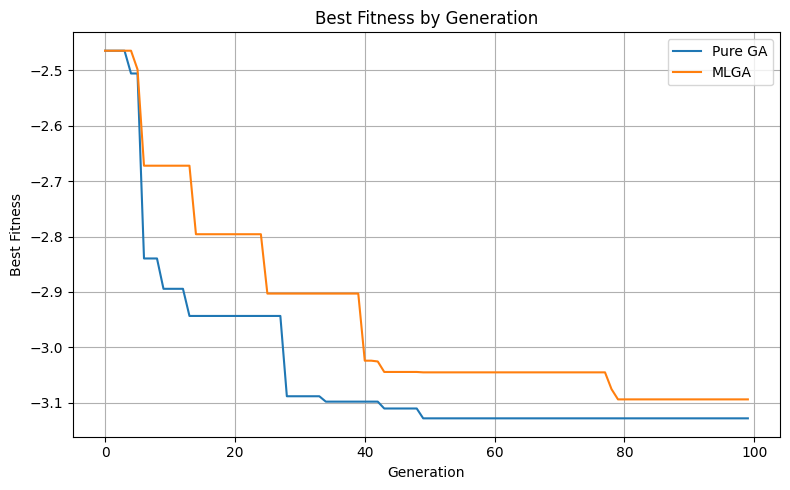

In [48]:
# =========================
# Plot best fitness by generation
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(pure_history_df["generation"], pure_history_df["best_fitness"], label="Pure GA")
plt.plot(mlga_history_df["generation"], mlga_history_df["best_fitness"], label="MLGA")
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Best Fitness by Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

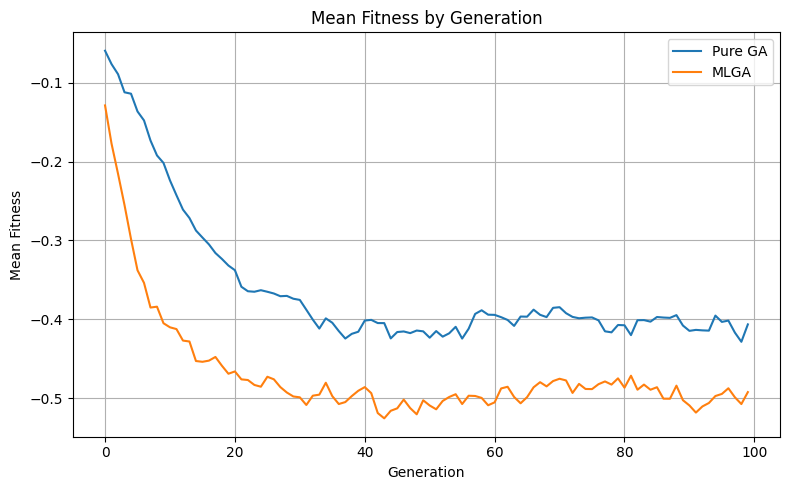

In [49]:
# =========================
# Plot mean fitness by generation
# =========================

plt.figure(figsize=(8, 5))
plt.plot(pure_history_df["generation"], pure_history_df["mean_fitness"], label="Pure GA")
plt.plot(mlga_history_df["generation"], mlga_history_df["mean_fitness"], label="MLGA")
plt.xlabel("Generation")
plt.ylabel("Mean Fitness")
plt.title("Mean Fitness by Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

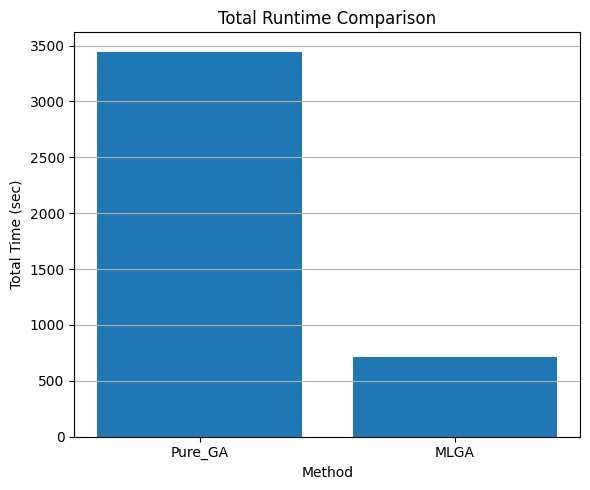

In [50]:
# =========================
# Plot total runtime comparison
# =========================

plt.figure(figsize=(6, 5))
plt.bar(compare_df["method"], compare_df["total_time_sec"])
plt.xlabel("Method")
plt.ylabel("Total Time (sec)")
plt.title("Total Runtime Comparison")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

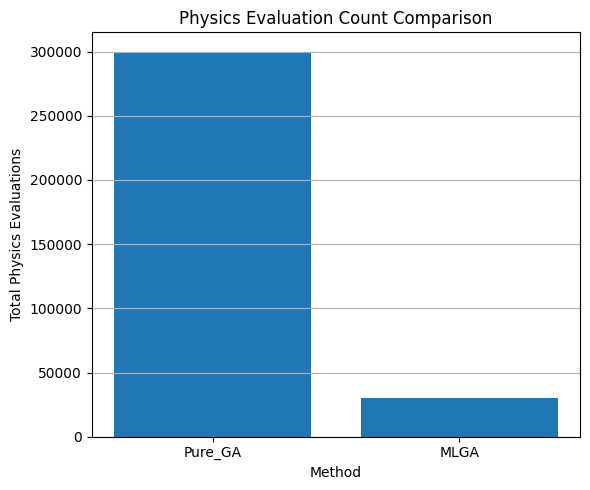

In [51]:
# =========================
# Plot physics evaluation count comparison
# =========================

plt.figure(figsize=(6, 5))
plt.bar(compare_df["method"], compare_df["total_physics_eval_count"])
plt.xlabel("Method")
plt.ylabel("Total Physics Evaluations")
plt.title("Physics Evaluation Count Comparison")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

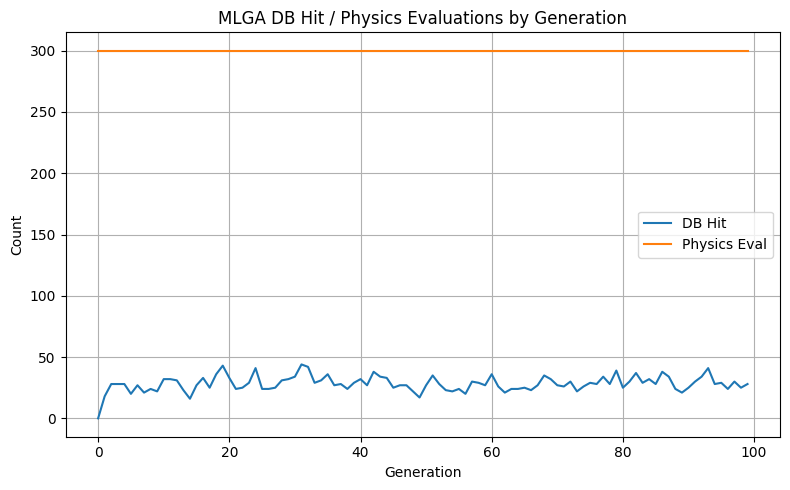

In [52]:
# =========================
# Plot MLGA DB-hit and physics evaluations
# =========================

plt.figure(figsize=(8, 5))
plt.plot(mlga_history_df["generation"], mlga_history_df.get("db_hit_count", pd.Series([0]*len(mlga_history_df))), label="DB Hit")
plt.plot(mlga_history_df["generation"], mlga_history_df.get("n_physics", pd.Series([0]*len(mlga_history_df))), label="Physics Eval")
plt.xlabel("Generation")
plt.ylabel("Count")
plt.title("MLGA DB Hit / Physics Evaluations by Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
# =========================
# Add best-fitness diagnostics
# =========================

def add_best_diagnostics(history_df: pd.DataFrame) -> pd.DataFrame:
    """
    Add diagnostic metrics related to best-fitness progression.

    This function computes several indicators useful for analyzing
    optimization behavior:

    - best_diff: change in best fitness between generations
    - best_improved: whether a new best solution was found
    - best_improve_amount: magnitude of improvement
    - best_improve_count_cum: cumulative improvement count
    - best_stagnation_gen: number of consecutive generations without improvement
    """
    df = history_df.copy()

    # Change in best fitness compared to the previous generation
    # Lower fitness is better, so diff < 0 indicates an improvement
    df["best_diff"] = df["best_fitness"].diff()

    # Whether the generation achieved a new global best
    df["best_improved"] = df["best_diff"].fillna(0) < 0

    # Improvement magnitude (keep positive values for readability)
    df["best_improve_amount"] = (-df["best_diff"]).clip(lower=0).fillna(0)

    # Cumulative number of best improvements
    df["best_improve_count_cum"] = df["best_improved"].astype(int).cumsum()

    # Number of consecutive generations without improvement
    stagnation_counter = []
    c = 0
    for improved in df["best_improved"]:
        if improved:
            c = 0
        else:
            c += 1
        stagnation_counter.append(c)
    df["best_stagnation_gen"] = stagnation_counter

    return df


pure_history_diag_df = add_best_diagnostics(pure_history_df)
mlga_history_diag_df = add_best_diagnostics(mlga_history_df)

display(pure_history_diag_df.head(10))
display(mlga_history_diag_df.head(10))

,generation,best_fitness,mean_fitness,db_hit_count,db_miss_count,selected_for_physics,n_physics,physics_time_sec,generation_time_sec,best_final_fitness,mean_final_fitness,best_diff,best_improved,best_improve_amount,best_improve_count_cum,best_stagnation_gen
0,0,-2.464264,-0.059351,0,3000,3000,3000,18.754986,18.754986,-2.464264,-0.059351,NaN,False,0.000000,0,1
1,1,-2.464264,-0.076327,0,3000,3000,3000,19.198821,19.198821,-2.464264,-0.076327,0.000000,False,-0.000000,0,2
2,2,-2.464264,-0.089129,0,3000,3000,3000,19.715076,19.715076,-2.464264,-0.089129,0.000000,False,-0.000000,0,3
3,3,-2.464264,-0.112105,0,3000,3000,3000,20.534713,20.534713,-2.464264,-0.112105,0.000000,False,-0.000000,0,4
4,4,-2.505396,-0.113897,0,3000,3000,3000,25.033025,25.033025,-2.505396,-0.113897,-0.041132,True,0.041132,1,0
5,5,-2.505396,-0.136400,0,3000,3000,3000,20.381435,20.381435,-2.505396,-0.136400,0.000000,False,-0.000000,1,1
6,6,-2.839524,-0.147790,0,3000,3000,3000,22.330405,22.330405,-2.839524,-0.147790,-0.334128,True,0.334128,2,0
7,7,-2.839524,-0.173258,0,3000,3000,3000,24.956176,24.956176,-2.839524,-0.173258,0.000000,False,-0.000000,2,1
8,8,-2.839524,-0.192202,0,3000,3000,3000,26.666865,26.666865,-2.839524,-0.192202,0.000000,False,-0.000000,2,2
9,9,-2.894319,-0.201707,0,3000,3000,3000,26.467775,26.467775,-2.894319,-0.201707,-0.054795,True,0.054795,3,0


,generation,best_fitness,mean_fitness,db_hit_count,db_miss_count,selected_for_physics,n_physics,db_time_sec,ml_time_sec,physics_time_sec,...,population_size,fitness_source_counts,best_final_fitness,mean_final_fitness,true_ok_ratio,best_diff,best_improved,best_improve_amount,best_improve_count_cum,best_stagnation_gen
0,0,-2.464264,-0.128753,0,3000,300,300,0.061329,0.532777,1.216285,...,3000,"{'ml': 2700, 'physics': 300}",-2.464264,-0.128753,0.320000,NaN,False,0.000000,0,1
1,1,-2.464264,-0.177233,18,2982,300,300,0.107409,0.786085,2.335096,...,3000,"{'ml': 2682, 'physics': 300, 'db': 18}",-2.464264,-0.177233,0.408805,0.000000,False,-0.000000,0,2
2,2,-2.464264,-0.215508,28,2972,300,300,0.073622,0.404529,1.605036,...,3000,"{'ml': 2672, 'physics': 300, 'db': 28}",-2.464264,-0.215508,0.417683,0.000000,False,-0.000000,0,3
3,3,-2.464264,-0.255219,28,2972,300,300,0.078150,0.431329,2.645577,...,3000,"{'ml': 2672, 'physics': 300, 'db': 28}",-2.464264,-0.255219,0.457317,0.000000,False,-0.000000,0,4
4,4,-2.464264,-0.298263,28,2972,300,300,0.078075,0.434007,1.596426,...,3000,"{'ml': 2672, 'physics': 300, 'db': 28}",-2.464264,-0.298263,0.460366,0.000000,False,-0.000000,0,5
5,5,-2.497973,-0.337890,20,2980,300,300,0.082988,0.404696,1.609624,...,3000,"{'ml': 2680, 'physics': 300, 'db': 20}",-2.497973,-0.337890,0.500000,-0.033709,True,0.033709,1,0
6,6,-2.671959,-0.353883,27,2973,300,300,0.085733,0.402797,1.731718,...,3000,"{'ml': 2673, 'physics': 300, 'db': 27}",-2.671959,-0.353883,0.525994,-0.173986,True,0.173986,2,0
7,7,-2.671959,-0.385185,21,2979,300,300,0.091520,0.425437,1.718691,...,3000,"{'ml': 2679, 'physics': 300, 'db': 21}",-2.671959,-0.385185,0.529595,0.000000,False,-0.000000,2,1
8,8,-2.671959,-0.384089,24,2976,300,300,0.150150,0.688154,1.510141,...,3000,"{'ml': 2676, 'physics': 300, 'db': 24}",-2.671959,-0.384089,0.509259,0.000000,False,-0.000000,2,2
9,9,-2.671959,-0.405085,22,2978,300,300,0.111178,0.389458,1.802610,...,3000,"{'ml': 2678, 'physics': 300, 'db': 22}",-2.671959,-0.405085,0.534161,0.000000,False,-0.000000,2,3


In [54]:
# =========================
# Best-fitness diagnostic summary
# =========================

def summarize_best_diagnostics(history_df: pd.DataFrame, method_name: str) -> pd.DataFrame:
    df = history_df.copy()

    improve_gens = df.loc[df["best_improved"], "generation"].tolist()
    improve_amounts = df.loc[df["best_improved"], "best_improve_amount"].tolist()

    summary = {
        "method": method_name,
        "n_generations": len(df),
        "n_best_improvements": int(df["best_improved"].sum()),
        "final_best_fitness": df["best_fitness"].iloc[-1] if len(df) > 0 else np.nan,
        "max_single_improvement": df["best_improve_amount"].max() if len(df) > 0 else np.nan,
        "avg_nonzero_improvement": (
            df.loc[df["best_improve_amount"] > 0, "best_improve_amount"].mean()
            if (df["best_improve_amount"] > 0).any() else 0.0
        ),
        "max_stagnation_gen": df["best_stagnation_gen"].max() if len(df) > 0 else np.nan,
        "improvement_generations": improve_gens,
        "improvement_amounts": improve_amounts,
    }

    return pd.DataFrame([summary])


best_diag_summary_df = pd.concat([
    summarize_best_diagnostics(pure_history_diag_df, "Pure_GA"),
    summarize_best_diagnostics(mlga_history_diag_df, "MLGA"),
], axis=0, ignore_index=True)

display(best_diag_summary_df)

,method,n_generations,n_best_improvements,final_best_fitness,max_single_improvement,avg_nonzero_improvement,max_stagnation_gen,improvement_generations,improvement_amounts
0,Pure_GA,100,8,-3.128290,0.334128,0.083003,50,"[4, 6, 9, 13, 28, 34, 43, 49]","[0.041131618211796006, 0.33412829553910406, 0...."
1,MLGA,100,10,-3.094049,0.173986,0.062979,28,"[5, 6, 14, 25, 40, 42, 43, 49, 78, 79]","[0.0337086478514208, 0.17398645731326257, 0.12..."


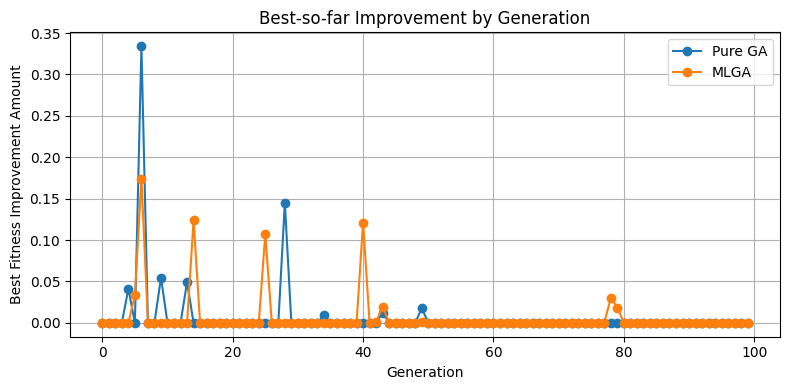

In [55]:
# =========================
# Plot best improvement amount by generation
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(
    pure_history_diag_df["generation"],
    pure_history_diag_df["best_improve_amount"],
    marker="o",
    label="Pure GA"
)
plt.plot(
    mlga_history_diag_df["generation"],
    mlga_history_diag_df["best_improve_amount"],
    marker="o",
    label="MLGA"
)

plt.xlabel("Generation")
plt.ylabel("Best Fitness Improvement Amount")
plt.title("Best-so-far Improvement by Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

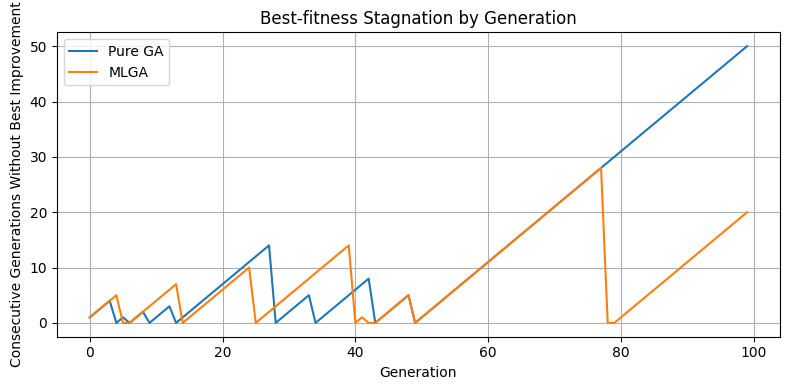

In [56]:
# =========================
# Plot stagnation length by generation
# =========================

plt.figure(figsize=(8, 4))
plt.plot(
    pure_history_diag_df["generation"],
    pure_history_diag_df["best_stagnation_gen"],
    label="Pure GA"
)
plt.plot(
    mlga_history_diag_df["generation"],
    mlga_history_diag_df["best_stagnation_gen"],
    label="MLGA"
)

plt.xlabel("Generation")
plt.ylabel("Consecutive Generations Without Best Improvement")
plt.title("Best-fitness Stagnation by Generation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [57]:
# =========================
# Show generations where best improved
# =========================

def show_best_improvement_events(history_df: pd.DataFrame, method_name: str):
    events = history_df.loc[history_df["best_improved"], [
        "generation",
        "best_fitness",
        "best_improve_amount",
        "best_stagnation_gen"
    ]].copy()

    print(f"\n=== {method_name} best improvement events ===")
    if len(events) == 0:
        print("No best-improvement event found.")
    else:
        display(events)


show_best_improvement_events(pure_history_diag_df, "Pure GA")
show_best_improvement_events(mlga_history_diag_df, "MLGA")


=== Pure GA best improvement events ===


,generation,best_fitness,best_improve_amount,best_stagnation_gen
4,4,-2.505396,0.041132,0
6,6,-2.839524,0.334128,0
9,9,-2.894319,0.054795,0
13,13,-2.943349,0.049030,0
28,28,-3.088396,0.145047,0
34,34,-3.098112,0.009716,0
43,43,-3.110507,0.012395,0
49,49,-3.128290,0.017783,0



=== MLGA best improvement events ===


,generation,best_fitness,best_improve_amount,best_stagnation_gen
5,5,-2.497973,0.033709,0
6,6,-2.671959,0.173986,0
14,14,-2.795734,0.123775,0
25,25,-2.902931,0.107197,0
40,40,-3.024137,0.121206,0
42,42,-3.025562,0.001425,0
43,43,-3.044504,0.018942,0
49,49,-3.045224,0.000720,0
78,78,-3.075496,0.030271,0
79,79,-3.094049,0.018554,0
